# Demo Notebook for Passive/Active Switching

## Setup/Loading Data

In [1]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.append("..")

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [2]:
import conllu
from conllu import Token, parse, parse_tree, parse_incr
from pyinflect import getAllInflections, getInflection
from src.utils import *
from src.units.word import *
from src.units.sentence import *

/Users/tzhang04/Desktop/active-passive-alternations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-30 12:22:41 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-04-30 12:22:41 INFO: Downloading default packages for language: en (English) ...
2026-04-30 12:22:41 INFO: File exists: /Users/tzhang04/stanza_resources/en/default.zip
2026-04-30 12:22:43 INFO: Finished downloading models and saved to /Users/tzhang04/stanza_resources
2026-04-30 12:22:43 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-30 12:22:44 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-04-30 12:22:44 INFO: Loading t

In [4]:
with open("../data/en_gum-ud-dev.conllu", "r") as f:
    text = f.read()
sentences = parse(text)

In [ ]:
i = 100
token = sentences[i][4]
print(sentences[i].metadata['text'])
list(sentences[i])

The announcement was first reprinted for humorous effect by the editor of the San Francisco Bulletin.


[{'id': 1,
  'form': 'The',
  'lemma': 'the',
  'upos': 'DET',
  'xpos': 'DT',
  'feats': {'Definite': 'Def', 'PronType': 'Art'},
  'head': 2,
  'deprel': 'det',
  'deps': [('det', 2)],
  'misc': {'Discourse': 'elaboration-additional:61->52:4:sem-synym-468-469,652-653-_+grf-col-480-_',
   'Entity': '(103-abstract-acc:com-nnnnn-cf2-2-sgl'}},
 {'id': 2,
  'form': 'announcement',
  'lemma': 'announcement',
  'upos': 'NOUN',
  'xpos': 'NN',
  'feats': {'Number': 'Sing'},
  'head': 5,
  'deprel': 'nsubj:pass',
  'deps': [('nsubj:pass', 5)],
  'misc': {'Entity': '103)', 'MSeg': 'announce-ment'}},
 {'id': 3,
  'form': 'was',
  'lemma': 'be',
  'upos': 'AUX',
  'xpos': 'VBD',
  'feats': {'Mood': 'Ind',
   'Number': 'Sing',
   'Person': '3',
   'Tense': 'Past',
   'VerbForm': 'Fin'},
  'head': 5,
  'deprel': 'aux:pass',
  'deps': [('aux:pass', 5)],
  'misc': None},
 {'id': 4,
  'form': 'first',
  'lemma': 'first',
  'upos': 'ADV',
  'xpos': 'RB',
  'feats': {'Degree': 'Pos', 'NumForm': 'Word', 

## Testing Sentence and PassiveSentence

In [5]:
new_sentences = []
for sent in sentences:
    s = Sentence(sent)
    new_sentences.append(s)

In [6]:
passive_sentences = [s for s in new_sentences if s.is_passive]

In [7]:
passive_sentences[0].text

'The direction of saccades is determined by an interaction between the goals of the observer and the physical properties of the different elements of the scene (e.g. colour, texture, brightness etc).'

In [8]:
build_subtree(passive_sentences[0][1])

[{'id': 1,
  'form': 'The',
  'lemma': 'the',
  'upos': 'DET',
  'xpos': 'DT',
  'feats': {'Definite': 'Def', 'PronType': 'Art'},
  'head': 2,
  'deprel': 'det',
  'deps': [('det', 2)],
  'misc': {'Discourse': 'elaboration-additional:39->36:2:sem-synym-369-370,380-386,391,401-402-_',
   'Entity': '(95-abstract-new-nnnnn-cf7-2-sgl',
   'PDTB': 'Implicit:Expansion.Level-of-detail.Arg2-as-detail:in particular:_:364-387:388-423'},
  'inflection': 'DT',
  'children': []},
 {'id': 2,
  'form': 'direction',
  'lemma': 'direction',
  'upos': 'NOUN',
  'xpos': 'NN',
  'feats': {'Number': 'Sing'},
  'head': 6,
  'deprel': 'nsubj:pass',
  'deps': [('nsubj:pass', 6)],
  'misc': {'MSeg': 'direct-ion'},
  'inflection': 'NN',
  'children': [{'id': 1,
    'form': 'The',
    'lemma': 'the',
    'upos': 'DET',
    'xpos': 'DT',
    'feats': {'Definite': 'Def', 'PronType': 'Art'},
    'head': 2,
    'deprel': 'det',
    'deps': [('det', 2)],
    'misc': {'Discourse': 'elaboration-additional:39->36:2:sem-

In [9]:
passive_sentences_test = []
i = 0
for sent in passive_sentences:
    try:
        new_sent = PassiveSentence(sent)
        passive_sentences_test.append(new_sent)
        active_sent = new_sent.depassivize()
        print(i)
        print(sent.text)
        print(f'{new_sent.passive_subject.text} | {new_sent.verb.text} | {new_sent.agent.text}')
        print(active_sent.text)
        i += 1
    except Exception as e:
        print("Failed:", sent.text)
        print("Error:", e, type(e))
    print()

0
The direction of saccades is determined by an interaction between the goals of the observer and the physical properties of the different elements of the scene (e.g. colour, texture, brightness etc).
The direction of saccades | is determined | by an interaction between the goals of the observer and the physical properties of the different elements of the scene (e.g. colour, texture, brightness etc)
An interaction between the goals of the observer and the physical properties of the different elements of the scene (e.g. colour, texture, brightness etc) determines the direction of saccades.

1
For example, differences in recruitment and retention strategies across departments will be washed out by averaging, thereby masking any insights into the efficacy of individual strategies and policies.
differences in recruitment and retention strategies across departments | will be washed | by averaging
For example, averaging will wash differences in recruitment and retention strategies across dep

In [10]:
getAllInflections('be')

{'VB': ('be',),
 'VBD': ('was', 'were'),
 'VBG': ('being',),
 'VBN': ('been',),
 'VBP': ('am', 'are'),
 'VBZ': ('is',)}

In [11]:
getAllInflections('do')

{'NN': ('do',),
 'NNS': ('dos', 'dos'),
 'VB': ('do',),
 'VBP': ('do',),
 'VBD': ('did', 'didst'),
 'VBN': ('done',),
 'VBG': ('doing',),
 'VBZ': ('does', 'dost', 'doth')}

In [12]:
getAllInflections('appreciate')

{'VB': ('appreciate',),
 'VBP': ('appreciate',),
 'VBD': ('appreciated',),
 'VBN': ('appreciated',),
 'VBG': ('appreciating',),
 'VBZ': ('appreciates',)}

In [13]:
passive_sentences_test[57]

[{'id': 1,
  'form': 'Moments',
  'lemma': 'moment',
  'upos': 'NOUN',
  'xpos': 'NNS',
  'feats': {'Number': 'Plur'},
  'head': 5,
  'deprel': 'nsubj',
  'deps': [('nsubj', 5)],
  'misc': {'Discourse': 'attribution-positive:154->155:1:sem-atsrc-1038-_+lex-indwd-1039-_',
   'MSeg': 'Moment-s'},
  'inflection': 'NNS',
  'children': [{'id': 3,
    'form': 'that',
    'lemma': 'that',
    'upos': 'PRON',
    'xpos': 'DT',
    'feats': {'Number': 'Sing', 'PronType': 'Dem'},
    'head': 1,
    'deprel': 'nmod',
    'deps': [('nmod:like', 1)],
    'misc': {'Entity': '(135-event-giv:act-nnnnn-cf1*-1-ana)'},
    'inflection': 'DT',
    'children': [{'id': 2,
      'form': 'like',
      'lemma': 'like',
      'upos': 'ADP',
      'xpos': 'IN',
      'feats': None,
      'head': 3,
      'deprel': 'case',
      'deps': [('case', 3)],
      'misc': None,
      'inflection': 'IN',
      'children': []}]}]},
 {'id': 2,
  'form': 'like',
  'lemma': 'like',
  'upos': 'ADP',
  'xpos': 'IN',
  'feats':

In [14]:
passive_sentences_test[69].depassivize().text

'Strong winds and heavy rain that led the crane to fall caused the accident, which occurred yesterday afternoon,.'

In [15]:
type(passive_sentences_test[69].depassivize())

src.units.sentence.Sentence

## Testing Document Conversion

In [5]:
from src.units.document import Document
from tqdm import tqdm

In [6]:
type(sentences)

list

In [7]:
sentences[28].metadata

{'text': 'References', 'sent_id': 'wik_eng_wikipedia_1.00002_x00003_13'}

In [19]:
doc = Document(sentences[:28])
print(doc)

Aesthetic Appreciation and Spanish Art: Insights from Eye-Tracking 
Claire Bailey-Ross claire.bailey-ross@port.ac.uk University of Portsmouth, United Kingdom 
Andrew Beresford a.m.beresford@durham.ac.uk Durham University, United Kingdom 
Daniel Smith daniel.smith2@durham.ac.uk Durham University, United Kingdom 
Claire Warwick c.l.h.warwick@durham.ac.uk Durham University, United Kingdom 
How do people look at and experience art? Which elements of specific artworks do they focus on? Do museum labels have an impact on how people look at artworks? The viewing experience of art is a complex one, involving issues of perception, attention, memory, decision-making, affect, and emotion. Thus, the time it takes and the ways of visually exploring an artwork can inform about its relevance, interestingness, and even its aesthetic appeal. This paper describes a collaborative pilot project focusing on a unique collection of 17th Century Zurbarán paintings. The Jacob cycle at Auckland Castle is the on

In [8]:
documents = []
curr_doc = []
for s in sentences:
    if "newdoc id" in s.metadata:
        if curr_doc:
            curr_doc = Document(curr_doc)
            documents.append(curr_doc)
        curr_doc = [s]
    else:
        curr_doc.append(s)
len(documents)

1082

In [9]:
converted_documents = []
for d in tqdm(documents):
    converted_documents += d.convert_all()

  2%|▏         | 19/1082 [00:00<00:11, 89.37it/s]

It is highly revered by the Bhil people and Noia sect who visit it in large numbers from Rajasthan, Madhya Pradesh and other parts of India.
VERB: revered / rever
AUXPASS INFL: VBZ
INFLECTIONS: {}
Error on doc wik_eng_wikipedia_1.00005_x00007, sentence 0
'NoneType' object is not subscriptable


  5%|▌         | 58/1082 [00:01<00:22, 45.86it/s]

In 1626, Garcia was overthrown by disgruntled nobles led by Manuel Jordao the Duke of Nsundi.
VERB: overthrown / overthrown
AUXPASS INFL: VBD
INFLECTIONS: {}
Error on doc wik_eng_wikipedia_1.00061_x00081, sentence 0
'NoneType' object is not subscriptable


 16%|█▌        | 172/1082 [00:03<00:11, 77.46it/s]

...

 74%|███████▎  | 797/1082 [00:22<00:13, 20.86it/s]

The Panel is co-chaired by Alexander Glaser and Zia Mian of Princeton University and Tatsujiro Suzuki of Nagasaki University, Japan.
VERB: co-chaired / co-chair
AUXPASS INFL: VBZ
INFLECTIONS: {}
Error on doc wik_eng_wikipedia_1.00787_x00974, sentence 3
'NoneType' object is not subscriptable


 96%|█████████▋| 1043/1082 [00:29<00:01, 33.86it/s]

The museum was co-founded by married couple Candace Frazee and Steve Lubanski, who started collecting the items after they began a tradition of giving each other new bunny gifts every day.
VERB: co-founded / co-found
AUXPASS INFL: VBD
INFLECTIONS: {}
Error on doc wik_eng_wikipedia_1.01043_x01300, sentence 1
'NoneType' object is not subscriptable


100%|██████████| 1082/1082 [00:33<00:00, 32.17it/s]


In [10]:
len([tup for tup in converted_documents if tup[2] != 'og']), sum([doc.num_passives + doc.num_actives for doc in documents]), len(converted_documents) / sum([doc.num_passives + doc.num_actives for doc in documents])

(4353, 4371, 0.9958819492107069)

In [11]:
len([tup for tup in converted_documents if tup[2] == 'p>a']), sum([doc.num_passives for doc in documents])

(657, 675)

In [12]:
len([tup for tup in converted_documents if tup[2] == 'a>p']), sum([doc.num_actives for doc in documents])

(3696, 3696)

In [20]:
pass_acts = list(filter(lambda sent: type(sent) in [PassiveSentence, ActiveSentence],
                   [sent for doc in documents for sent in doc]))

In [23]:
passive_errors = []
active_errors = []
for sentence in pass_acts:
    if type(sentence) == ActiveSentence:
        try:
            sentence.passivize()
        except Exception as e:
            print(e)
            active_errors.append(sentence)
    else:
        try:
            sentence.depassivize()
        except Exception as e:
            print(e)
            passive_errors.append(sentence)

It is highly revered by the Bhil people and Noia sect who visit it in large numbers from Rajasthan, Madhya Pradesh and other parts of India.
VERB: revered / rever
AUXPASS INFL: VBZ
INFLECTIONS: {}
'NoneType' object is not subscriptable
In 1626, Garcia was overthrown by disgruntled nobles led by Manuel Jordao the Duke of Nsundi.
VERB: overthrown / overthrown
AUXPASS INFL: VBD
INFLECTIONS: {}
'NoneType' object is not subscriptable
Francisquita is then wooed by the Don Mathias, Fernando's father, in the presence of Dona Francisca, Francisquita's mother.
VERB: wooed / wooe
AUXPASS INFL: VBZ
INFLECTIONS: {}
'NoneType' object is not subscriptable
It is accredited by and a member of Canadian Accredited Independent Schools.
VERB: accredited / accredite
AUXPASS INFL: VBZ
INFLECTIONS: {}
'NoneType' object is not subscriptable
UCLA Extension is accredited, through UCLA, by the Western Association of Schools and Colleges.
VERB: accredited / accredite
AUXPASS INFL: VBZ
INFLECTIONS: {}
'NoneType' ob

In [25]:
len(active_errors), len(passive_errors)

(0, 18)

In [30]:
for sentence in passive_errors:
    print(sentence.text)
    print("VERB:", sentence.verb_word['lemma'], "/", sentence.verb_word,)
    # print("AUXPASS:", sentence.auxpass)
    # print("INFLECTIONS:", getAllInflections(sentence.verb_word['lemma']))
    print()

It is highly revered by the Bhil people and Noia sect who visit it in large numbers from Rajasthan, Madhya Pradesh and other parts of India.
VERB: rever / revered

In 1626, Garcia was overthrown by disgruntled nobles led by Manuel Jordao the Duke of Nsundi.
VERB: overthrown / overthrown

Francisquita is then wooed by the Don Mathias, Fernando's father, in the presence of Dona Francisca, Francisquita's mother.
VERB: wooe / wooed

It is accredited by and a member of Canadian Accredited Independent Schools.
VERB: accredite / accredited

UCLA Extension is accredited, through UCLA, by the Western Association of Schools and Colleges.
VERB: accredite / accredited

Original only as a 7" EP, it was later re-released on CD by Relapse Records.
VERB: re-release / re-released

Waterreus, however, eventually came under fire from Rangers fans following his criticism of the club in a Dutch newspaper, which was misinterpreted by the fans as a result of poor journalism.
VERB: misinterppret / misinterpre

In [23]:
with open("../plots/factual_example.txt", 'w') as f:
    f.write(documents[0].text)

In [24]:
with open("../plots/counterfactual_example.txt", 'w') as f:
    f.write(converted_documents[1][0].text)

### Test surprisal calc

In [5]:
from src.uid import *

In [39]:
def my_generator(low, high):
    while low <= high:
        yield low
        low += 1

In [40]:
test_gen = my_generator(2, 8)

In [26]:
tokenizer, model, device = load_lm(device='mps')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 2254.19it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
fact = [s.text for s in documents[0]]
cfact = [s.text for s in converted_documents[1][0]]

In [29]:
converted_documents[1][1]

11

In [34]:
fsentence = fact[11]
sentence = cfact[11]

In [35]:
fsentence

'This paper describes a collaborative pilot project focusing on a unique collection of 17th Century Zurbarán paintings.'

In [53]:
token_cf, surprisals_cf = compute_surprisal(
    sentence,
    "_",
    cfact,
    11,
    tokenizer,
    model,
    device=device,
    uid_level="document",
    verbose=True
)

In [54]:
len(surprisals)

868

In [55]:
token_f, surprisals_f = compute_surprisal(
    fsentence,
    "_",
    fact,
    11,
    tokenizer,
    model,
    device=device,
    uid_level="document",
    verbose=True
)

In [67]:
surprisals_cf = np.array(surprisals_cf)

In [68]:
surprisals_f = np.array(surprisals_f)

In [69]:
(np.array(token_cf) == np.array(token_f + [".", "."])).mean()

np.float64(0.23448275862068965)

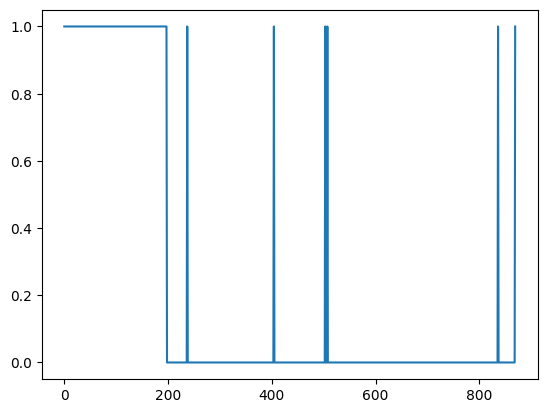

In [70]:
import matplotlib.pyplot as plt
plt.plot(np.array(token_cf) == np.array(token_f + [".", "."]))

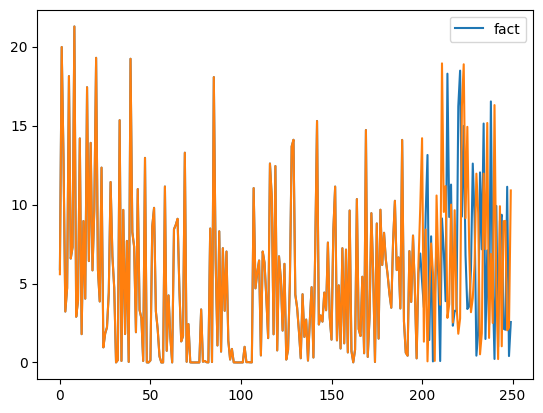

In [71]:
plt.plot(surprisals_f[:250], label='fact')
plt.plot(surprisals_cf[:250])
plt.legend()

## Testing Document Generator

In [4]:
from src.uid import *

In [22]:
%%timeit
# [doc_tuple for doc_tuple in docs_generator]
docs_generator = iter_docs("../data/en_gum-ud-dev.conllu", gen_cf=True)
" ".join(sent for doc_tuple in docs_generator for sent in doc_tuple[0][1])

2.06 s ± 34.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
def test_generator(num):
    start = 0
    while start < num:
        if start % 2 == 0:
            yield start
        start += 1

In [19]:
x = test_generator(6)

In [23]:
next(x)

StopIteration: 